# Лабораторна робота 3 

- **Тип 1**: рівномірний розподіл,
- **Тип 2**: нормальний розподіл,
- **Тип 3**: рівномірний розподіл.


In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Ellipse

np.set_printoptions(precision=3, suppress=True)
plt.style.use('seaborn-v0_8-whitegrid')


In [60]:
# geometric helpers adapted from lab1
def cross(o, a, b):
    return (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])


def convex_hull(points):
    pts = np.asarray(points)
    n = len(pts)
    if n < 3:
        return np.arange(n)

    idx_ymin = np.argmin(pts[:, 1])
    y_min = pts[idx_ymin, 1]
    cand = np.where(pts[:, 1] == y_min)[0]
    start = cand[np.argmin(pts[cand, 0])]

    angles = np.arctan2(pts[:, 1]-pts[start, 1], pts[:, 0]-pts[start, 0])
    dists = np.sum((pts - pts[start])**2, axis=1)
    order = np.lexsort((-dists, angles))
    order = order[order != start]
    order = np.concatenate([[start], order])

    stack = [order[0], order[1]]
    for i in range(2, n):
        k = order[i]
        while len(stack) >= 2 and cross(pts[stack[-2]], pts[stack[-1]], pts[k]) <= 0:
            stack.pop()
        stack.append(k)
    return np.array(stack)


def scale_to_square(pts, x_c, y_c, k, scale_x):
    out = pts.copy().astype(float)
    if scale_x:
        out[:, 0] = (out[:, 0] - x_c) / k + x_c
    else:
        out[:, 1] = (out[:, 1] - y_c) / k + y_c
    return out


def centroids_by_class(class_points):
    return {name: pts.mean(axis=0) for name, pts in class_points.items()}


def pairwise_distances(point, centroids):
    names = list(centroids.keys())
    centers = np.array([centroids[n] for n in names])
    diffs = centers - point
    d_l2 = np.sqrt(np.sum(diffs ** 2, axis=1))
    d_l1 = np.sum(np.abs(diffs), axis=1)
    return names, d_l2, d_l1


def classify_point(point, centroids):
    names, d_l2, d_l1 = pairwise_distances(point, centroids)
    pred_l2 = names[int(np.argmin(d_l2))]
    pred_l1 = names[int(np.argmin(d_l1))]
    return names, d_l2, d_l1, pred_l2, pred_l1


def classify_many(test_points, centroids):
    out = []
    for i, p in enumerate(test_points, start=1):
        names, d_l2, d_l1, pred_l2, pred_l1 = classify_point(p, centroids)
        row = {"idx": i, "x": p[0], "y": p[1], "pred_L2": pred_l2, "pred_L1": pred_l1}
        for n, v in zip(names, d_l2):
            row[f"L2_{n}"] = v
        for n, v in zip(names, d_l1):
            row[f"L1_{n}"] = v
        out.append(row)
    return out


## Генерація даних


In [61]:
SEED = 24
rng = np.random.default_rng(SEED)

N_PER_CLASS = 100
N_TEST = 100

class_specs = {
    "Тип 1": {"mode": "uniform", "low": np.array([-13.0, 1.0]), "high": np.array([-4.0, 8.0]), "color": "tab:red"},
    "Тип 2": {"mode": "normal",  "mean": np.array([4.5, 5.5]),  "std": np.array([1.8, 1.4]), "color": "tab:blue"},
    "Тип 3": {"mode": "uniform", "low": np.array([-1.0, -8.0]), "high": np.array([7.0, -1.5]), "color": "tab:green"},
}

class_points = {}
for name, spec in class_specs.items():
    if spec["mode"] == "uniform":
        x = rng.uniform(spec["low"][0], spec["high"][0], size=N_PER_CLASS)
        y = rng.uniform(spec["low"][1], spec["high"][1], size=N_PER_CLASS)
    else:
        x = rng.normal(spec["mean"][0], spec["std"][0], size=N_PER_CLASS)
        y = rng.normal(spec["mean"][1], spec["std"][1], size=N_PER_CLASS)
    class_points[name] = np.column_stack([x, y])

centroids = centroids_by_class(class_points)

all_train = np.vstack(list(class_points.values()))
mins = all_train.min(axis=0) - 1.5
maxs = all_train.max(axis=0) + 1.5

test_points = np.column_stack([
    rng.uniform(mins[0], maxs[0], size=N_TEST),
    rng.uniform(mins[1], maxs[1], size=N_TEST),
])

for n, c in centroids.items():
    print(n, np.round(c, 4))


Тип 1 [-8.524  4.253]
Тип 2 [4.215 5.641]
Тип 3 [ 2.621 -4.604]


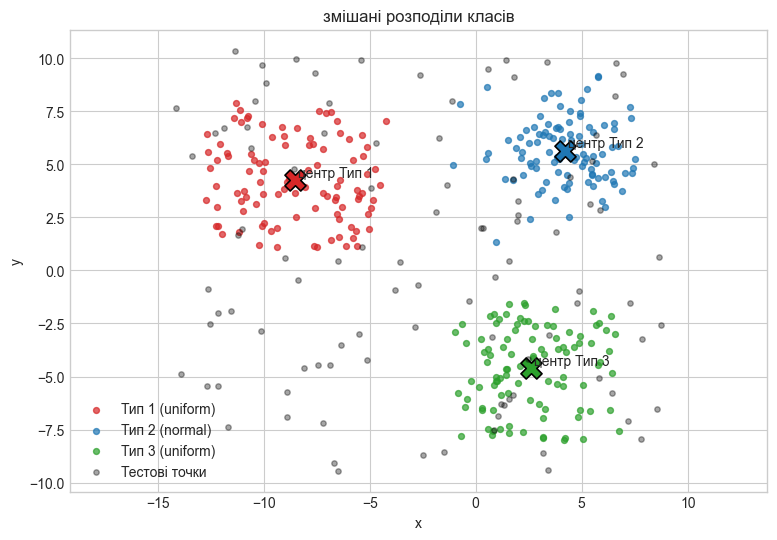

In [62]:
fig, ax = plt.subplots(figsize=(9,6))
for name, pts in class_points.items():
    ax.scatter(pts[:,0], pts[:,1], s=18, alpha=0.7, color=class_specs[name]['color'], label=f"{name} ({class_specs[name]['mode']})")

for name, c in centroids.items():
    ax.scatter(c[0], c[1], s=230, marker='X', edgecolor='black', linewidth=1.2, color=class_specs[name]['color'])
    ax.text(c[0]+0.15, c[1]+0.15, f"центр {name}")

ax.scatter(test_points[:,0], test_points[:,1], s=15, color='black', alpha=0.35, label='Тестові точки')
ax.set_title('змішані розподіли класів')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.axis('equal'); ax.legend(loc='best')
plt.show()


In [63]:
results = classify_many(test_points, centroids)

print('Перші 12 результатів:')
for r in results[:12]:
    print(f"#{r['idx']:3d}: ({r['x']:.2f}, {r['y']:.2f}) | L2={r['pred_L2']} | L1={r['pred_L1']}")


Перші 12 результатів:
#  1: (-1.50, -8.55) | L2=Тип 3 | L1=Тип 3
#  2: (-10.07, 9.69) | L2=Тип 1 | L1=Тип 1
#  3: (8.63, 0.62) | L2=Тип 2 | L1=Тип 2
#  4: (-7.45, -4.47) | L2=Тип 1 | L1=Тип 1
#  5: (-4.68, 6.02) | L2=Тип 1 | L1=Тип 1
#  6: (1.56, -6.08) | L2=Тип 3 | L1=Тип 3
#  7: (-9.91, 8.82) | L2=Тип 1 | L1=Тип 1
#  8: (-12.14, -5.44) | L2=Тип 1 | L1=Тип 1
#  9: (-8.55, 4.77) | L2=Тип 1 | L1=Тип 1
# 10: (1.78, -5.88) | L2=Тип 3 | L1=Тип 3
# 11: (7.28, -1.55) | L2=Тип 3 | L1=Тип 3
# 12: (-12.65, -5.44) | L2=Тип 1 | L1=Тип 1


In [64]:
mismatch = [r for r in results if r['pred_L2'] != r['pred_L1']]
names = list(class_points.keys())
counts_l2 = {n: sum(1 for r in results if r['pred_L2'] == n) for n in names}
counts_l1 = {n: sum(1 for r in results if r['pred_L1'] == n) for n in names}

print(f"Кількість тестових точок: {len(results)}")
print(f"Розбіжностей між L2 та L1: {len(mismatch)}")
print('Розподіл рішень L2:', counts_l2)
print('Розподіл рішень L1:', counts_l1)


Кількість тестових точок: 100
Розбіжностей між L2 та L1: 4
Розподіл рішень L2: {'Тип 1': 43, 'Тип 2': 25, 'Тип 3': 32}
Розподіл рішень L1: {'Тип 1': 41, 'Тип 2': 25, 'Тип 3': 34}


In [65]:
headers = ['idx', 'x', 'y', 'pred_L2', 'pred_L1']
print(f"{headers[0]:>4} | {headers[1]:>8} | {headers[2]:>8} | {headers[3]:>7} | {headers[4]:>7}")
print('-' * 48)
for r in results[:15]:
    print(f"{r['idx']:4d} | {r['x']:8.3f} | {r['y']:8.3f} | {r['pred_L2']:>7} | {r['pred_L1']:>7}")


 idx |        x |        y | pred_L2 | pred_L1
------------------------------------------------
   1 |   -1.496 |   -8.546 |   Тип 3 |   Тип 3
   2 |  -10.070 |    9.686 |   Тип 1 |   Тип 1
   3 |    8.628 |    0.621 |   Тип 2 |   Тип 2
   4 |   -7.454 |   -4.472 |   Тип 1 |   Тип 1
   5 |   -4.679 |    6.022 |   Тип 1 |   Тип 1
   6 |    1.557 |   -6.082 |   Тип 3 |   Тип 3
   7 |   -9.908 |    8.822 |   Тип 1 |   Тип 1
   8 |  -12.140 |   -5.443 |   Тип 1 |   Тип 1
   9 |   -8.551 |    4.767 |   Тип 1 |   Тип 1
  10 |    1.779 |   -5.877 |   Тип 3 |   Тип 3
  11 |    7.279 |   -1.550 |   Тип 3 |   Тип 3
  12 |  -12.648 |   -5.440 |   Тип 1 |   Тип 1
  13 |   -7.134 |    6.470 |   Тип 1 |   Тип 1
  14 |  -14.129 |    7.640 |   Тип 1 |   Тип 1
  15 |   -0.325 |   -1.431 |   Тип 3 |   Тип 3


In [66]:
point_idx = 0
p = test_points[point_idx]
names, d_l2, d_l1, pred_l2, pred_l1 = classify_point(p, centroids)

print(f"Тестова точка #{point_idx+1}: ({p[0]:.3f}, {p[1]:.3f})")
for n, a, b in zip(names, d_l2, d_l1):
    print(f"{n}: L2={a:.3f}, L1={b:.3f}")
print('Рішення L2:', pred_l2)
print('Рішення L1:', pred_l1)


Тестова точка #1: (-1.496, -8.546)
Тип 1: L2=14.601, L1=19.826
Тип 2: L2=15.293, L1=19.898
Тип 3: L2=5.700, L1=8.059
Рішення L2: Тип 3
Рішення L1: Тип 3


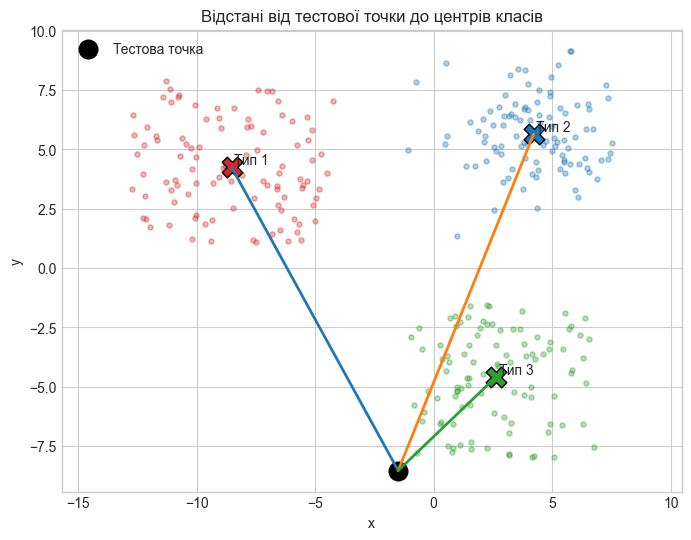

In [67]:
fig, ax = plt.subplots(figsize=(8,6))
for name, pts in class_points.items():
    ax.scatter(pts[:,0], pts[:,1], s=14, alpha=0.35, color=class_specs[name]['color'])
for name, c in centroids.items():
    ax.scatter(c[0], c[1], s=220, marker='X', color=class_specs[name]['color'], edgecolor='black', linewidth=1)
    ax.plot([p[0], c[0]], [p[1], c[1]], linewidth=2)
    ax.text(c[0]+0.12, c[1]+0.12, name)
ax.scatter(p[0], p[1], s=180, color='black', marker='o', label='Тестова точка')
ax.set_title('Відстані від тестової точки до центрів класів')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend(loc='best'); ax.axis('equal')
plt.show()


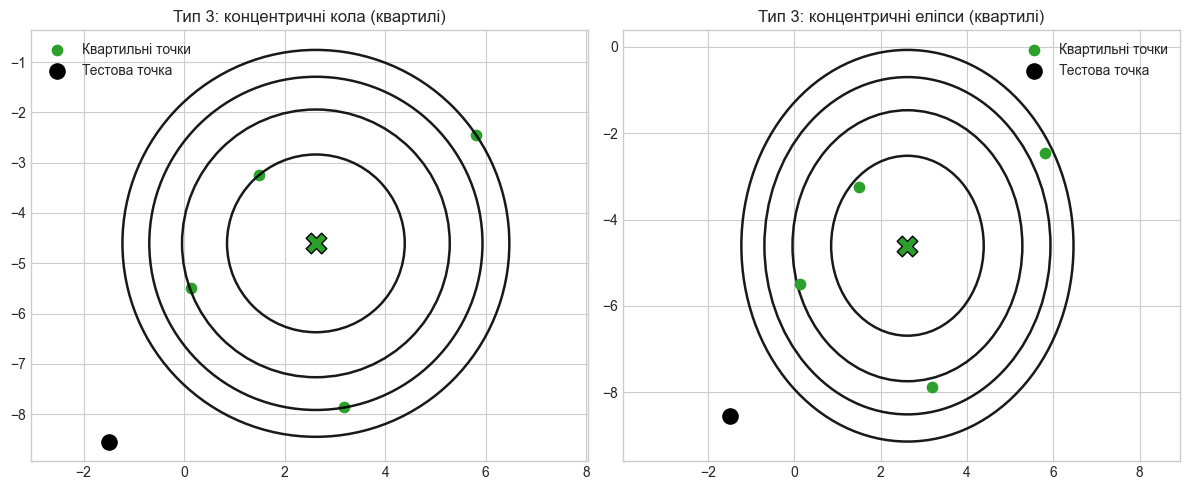

In [68]:
focus_class = 'Тип 3'
center = centroids[focus_class]
pts = class_points[focus_class]
radii = np.sqrt(np.sum((pts - center)**2, axis=1))
q_levels = np.array([0.25, 0.5, 0.75, 0.9])
r_levels = np.quantile(radii, q_levels)

# Quartile representatives: choose real class points closest to quartile radii.
q_idx = [int(np.argmin(np.abs(radii - r))) for r in r_levels]
q_points = pts[q_idx]

# Use the same global test point p for all visualizations.
fig, axes = plt.subplots(1,2, figsize=(12,5))
ax1, ax2 = axes

# Draw only quartile representatives instead of all class points.
ax1.scatter(q_points[:,0], q_points[:,1], s=55, color=class_specs[focus_class]['color'], label='Квартильні точки')
ax1.scatter(center[0], center[1], s=220, marker='X', color=class_specs[focus_class]['color'], edgecolor='black')
ax1.scatter(p[0], p[1], s=120, color='black', label='Тестова точка')
for r in r_levels:
    ax1.add_patch(Circle((center[0], center[1]), r, fill=False, linewidth=1.8, alpha=0.9))
ax1.set_title(f"{focus_class}: концентричні кола (квартилі)")
ax1.axis('equal')
ax1.legend(loc='best')

all_pts = np.vstack(list(class_points.values()))
min_xy = all_pts.min(axis=0)
max_xy = all_pts.max(axis=0)
width, height = (max_xy - min_xy)
k = max(width, height) / min(width, height)
scale_x = width < height

for r in r_levels:
    if scale_x:
        e_w, e_h = 2*r*k, 2*r
    else:
        e_w, e_h = 2*r, 2*r*k
    ax2.add_patch(Ellipse((center[0], center[1]), e_w, e_h, fill=False, linewidth=1.8, alpha=0.9))

ax2.scatter(q_points[:,0], q_points[:,1], s=55, color=class_specs[focus_class]['color'], label='Квартильні точки')
ax2.scatter(center[0], center[1], s=220, marker='X', color=class_specs[focus_class]['color'], edgecolor='black')
ax2.scatter(p[0], p[1], s=120, color='black', label='Тестова точка')
ax2.set_title(f"{focus_class}: концентричні еліпси (квартилі)")
ax2.axis('equal')
ax2.legend(loc='best')
plt.tight_layout(); plt.show()


In [69]:
cent_arr = np.array([centroids['Тип 1'], centroids['Тип 2'], centroids['Тип 3']])
mid_12 = 0.5*(cent_arr[0] + cent_arr[1])
near_border = 0.97*mid_12 + 0.03*cent_arr[2]
edge_cases = np.vstack([mid_12, near_border, cent_arr[2]])
edge_results = classify_many(edge_cases, centroids)
for r in edge_results:
    print(f"Edge#{r['idx']}: ({r['x']:.3f}, {r['y']:.3f}) -> L2={r['pred_L2']}, L1={r['pred_L1']}")


Edge#1: (-2.154, 4.947) -> L2=Тип 1, L1=Тип 1
Edge#2: (-2.011, 4.660) -> L2=Тип 2, L1=Тип 1
Edge#3: (2.621, -4.604) -> L2=Тип 3, L1=Тип 3
